# Cuaderno 4 — Explicabilidad del modelo (SHAP)

**Tesis:** Predicción del Punto de Equilibrio de Flujo de Caja en Empresas de Crecimiento  
**Autores:** Andrea Meneses · Juan Ramos  
**Universidad EAFIT · 2026**

---

## Objetivo

Explicar por qué el modelo predice lo que predice — tanto a nivel global (qué variables importan más en general) como a nivel individual (por qué el modelo tomó esta decisión para esta empresa específica).

---

## ¿Qué es SHAP?

SHAP (*SHapley Additive exPlanations*) es un método de explicabilidad basado en teoría de juegos cooperativos. Para cada predicción, SHAP calcula cuánto contribuyó cada variable a empujar la probabilidad hacia arriba (favorece breakeven) o hacia abajo (desfavorece breakeven).

A diferencia de la importancia Gini del Random Forest — que solo dice qué variables usa el modelo más frecuentemente — SHAP dice **en qué dirección** y **con qué intensidad** empuja cada variable para cada empresa específica.

**Ejemplo de lectura:** si el valor SHAP de `retained_earnings` para una empresa es +0.05, significa que esa variable empujó la probabilidad de breakeven 5 puntos porcentuales hacia arriba respecto al promedio del dataset.

---

## SHAP sobre el Ensemble

El modelo final es un ensemble que promedia las probabilidades de Random Forest y LightGBM. SHAP se calcula independientemente para cada modelo usando `TreeExplainer` — el método más preciso para modelos de árboles — y luego se promedian los valores SHAP. Este enfoque es metodológicamente equivalente a promediar las predicciones: las explicaciones del ensemble son el promedio de las explicaciones individuales.

---

## Contexto del análisis

El análisis se realiza sobre las **2.694 observaciones de 2024** — el conjunto de test más reciente del walk-forward, nunca visto por el modelo durante el entrenamiento. Esto garantiza que las explicaciones reflejan el comportamiento real del modelo en condiciones de predicción genuina.

> **Referencia:** Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems*, 30.

## 1. Configuración inicial y carga de datos

Se cargan los dos modelos del ensemble entrenados en el Cuaderno 3 — Random Forest y LightGBM — junto con la lista de 65 features que usan. El dataset base proviene del Cuaderno 2 (27.382 observaciones de empresas del Russell 2500 con FCF negativo que contienen datos desde el 2008 hasta el 2024), pero las features temporales — cambios trimestrales y rezagos — se reconstruyen aquí porque no se guardaron en el CSV para mantener el archivo liviano.

El análisis se enfoca en las **2.694 observaciones test del año 2024** — el último fold del walk-forward, nunca visto por el modelo durante el entrenamiento. Trabajar con datos no vistos garantiza que las explicaciones SHAP reflejan el comportamiento real del modelo en condiciones de predicción genuina, no su comportamiento memorizado sobre datos de entrenamiento.

In [1]:
import shap
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

warnings.filterwarnings("ignore")

# Identidad visual
juan_colors = ['#101B4B', '#545E85', '#A3A8B2', '#E7E7E7', '#0F19C9', '#F6D673']
FUENTE = "STIXGeneral"

def estilo_ax(ax, orientacion="vertical"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    if orientacion == "vertical":
        ax.spines["left"].set_visible(False)
        ax.yaxis.grid(True, linestyle="-", color=juan_colors[3], linewidth=0.8)
        ax.xaxis.grid(False)
    else:
        ax.spines["bottom"].set_visible(False)
        ax.xaxis.grid(True, linestyle="-", color=juan_colors[3], linewidth=0.8)
        ax.yaxis.grid(False)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)

# Cargar ambos modelos del ensemble
with open("../salidas/modelo_rf_final.pkl", "rb") as f:
    rf_final = pickle.load(f)
with open("../salidas/modelo_lgbm_final.pkl", "rb") as f:
    lgbm_final = pickle.load(f)

features_con_momentum = pd.read_csv("../salidas/features_modelo.csv").iloc[:, 0].tolist()

# Cargar dataset y reconstruir features temporales
df = pd.read_csv("../datos/procesados/dataset_modelo.csv")
df["end"] = pd.to_datetime(df["end"])
df["ano"] = df["end"].dt.year
df = df.sort_values(["ticker", "end"])

vars_momentum = ["fcf_operativo", "utilidad_neta", "caja",
                 "burn_rate", "margen_bruto", "ingresos"]
vars_rezago   = ["fcf_operativo", "utilidad_neta", "caja", "burn_rate"]

for var in vars_momentum:
    df[f"{var}_cambio"]     = df.groupby("ticker", observed=True)[var].diff()
    df[f"{var}_cambio_pct"] = df.groupby("ticker", observed=True)[var].pct_change(fill_method=None)
for var in vars_rezago:
    df[f"{var}_lag2"] = df.groupby("ticker", observed=True)[var].shift(2)
    df[f"{var}_lag4"] = df.groupby("ticker", observed=True)[var].shift(4)

df[features_con_momentum] = df[features_con_momentum].replace([np.inf, -np.inf], np.nan)
df_2024 = df[df["ano"] == 2024].copy().reset_index(drop=True)

# Probabilidades del ensemble
prob_rf   = rf_final.predict_proba(df_2024[features_con_momentum].values)[:, 1]
prob_lgbm = lgbm_final.predict_proba(df_2024[features_con_momentum].values)[:, 1]
df_2024["prob_breakeven"] = (prob_rf + prob_lgbm) / 2

print(f"Observaciones 2024: {len(df_2024):,} — empresas del Russell 2500 con FCF negativo en 2024")
print(f"Features del modelo: {len(features_con_momentum)} ({len(features_con_momentum)-16} originales + 16 temporales)")
print(f"Probabilidad media de breakeven en 2024: {df_2024['prob_breakeven'].mean():.3f}")
print(f"  → El modelo predice que el {df_2024['prob_breakeven'].mean()*100:.1f}% de las empresas alcanzará el breakeven en los próximos 4 trimestres")

/home/vscode/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Observaciones 2024: 2,694 — empresas del Russell 2500 con FCF negativo en 2024
Features del modelo: 65 (49 originales + 16 temporales)
Probabilidad media de breakeven en 2024: 0.458
  → El modelo predice que el 45.8% de las empresas alcanzará el breakeven en los próximos 4 trimestres


## 2. Cálculo de valores SHAP del ensemble

Se calculan los valores SHAP para cada modelo por separado y luego se promedian, de forma consistente con cómo el ensemble promedia las probabilidades.

> ⚠️ **Esta celda tarda ~10 minutos.**

In [2]:
# SHAP para Random Forest
print("Calculando SHAP para Random Forest...")
X_rf       = rf_final.named_steps["imputer"].transform(
    df_2024[features_con_momentum].values)
shap_rf    = shap.TreeExplainer(rf_final.named_steps["model"]).shap_values(X_rf)
sv_rf      = shap_rf[1] if isinstance(shap_rf, list) else shap_rf[:, :, 1]

# SHAP para LightGBM
print("Calculando SHAP para LightGBM...")
X_lgbm     = lgbm_final.named_steps["imputer"].transform(
    df_2024[features_con_momentum].values)
shap_lgbm  = shap.TreeExplainer(lgbm_final.named_steps["model"]).shap_values(X_lgbm)
sv_lgbm    = shap_lgbm[1] if isinstance(shap_lgbm, list) else shap_lgbm

# Promediar — equivalente a promediar probabilidades en el ensemble
sv = (sv_rf + sv_lgbm) / 2

# Importancia global
importancia_global = pd.Series(
    np.abs(sv).mean(axis=0),
    index=features_con_momentum
).sort_values(ascending=False)

print(f"Shape SHAP ensemble: {sv.shape} — {sv.shape[0]:,} observaciones × {sv.shape[1]} features")
print(f"Cada celda contiene el impacto de esa variable en esa observación específica.")
print(f"\nTop 10 variables por importancia SHAP global (promedio del impacto absoluto):")
print(importancia_global.head(10).round(4).to_string())

Calculando SHAP para Random Forest...
Calculando SHAP para LightGBM...
Shape SHAP ensemble: (2694, 65) — 2,694 observaciones × 65 features
Cada celda contiene el impacto de esa variable en esa observación específica.

Top 10 variables por importancia SHAP global (promedio del impacto absoluto):
retained_earnings     0.1192
pasivos_corrientes    0.1094
ratio_corriente       0.0826
capex                 0.0813
ppe_neto              0.0744
recompra_acciones     0.0632
gastos_id             0.0609
utilidad_operativa    0.0568
gastos_sga            0.0417
cambio_inventario     0.0386


## 3. Importancia global de variables

### 3.1 Comparación SHAP vs Gini

La importancia Gini del Random Forest mide qué tan frecuentemente usa el modelo cada variable para hacer divisiones. SHAP es más informativo: mide el impacto real en las predicciones, considerando tanto la frecuencia de uso como la magnitud del efecto.

Ambas métricas coinciden en las variables más importantes — `retained_earnings`, `capex`, `pasivos_corrientes` — lo que da mayor confianza en la robustez de los resultados.

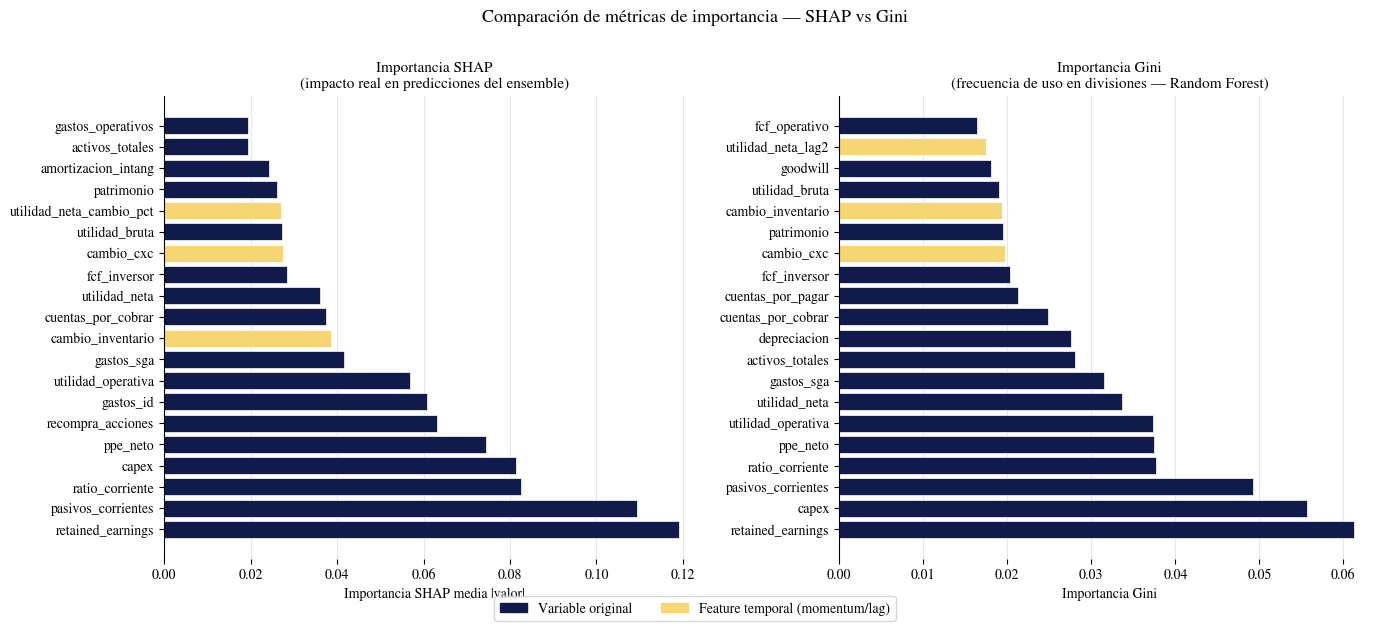

In [3]:
importancia_gini = pd.Series(
    rf_final.named_steps["model"].feature_importances_,
    index=features_con_momentum
).sort_values(ascending=False)

top20_shap = importancia_global.head(20)
top20_gini = importancia_gini.head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, top20, titulo, xlabel in [
    (axes[0], top20_shap,
     "Importancia SHAP\n(impacto real en predicciones del ensemble)",
     "Importancia SHAP media |valor|"),
    (axes[1], top20_gini,
     "Importancia Gini\n(frecuencia de uso en divisiones — Random Forest)",
     "Importancia Gini"),
]:
    estilo_ax(ax, "horizontal")
    colores = [juan_colors[5] if any(s in v for s in ["cambio", "lag", "pct"])
               else juan_colors[0] for v in top20.index]
    ax.barh(top20.index, top20.values,
            color=colores, edgecolor="white", linewidth=0.5)
    ax.set_title(titulo, fontfamily=FUENTE, fontsize=11)
    ax.set_xlabel(xlabel, fontfamily=FUENTE)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)

patch_orig  = mpatches.Patch(color=juan_colors[0], label="Variable original")
patch_tempo = mpatches.Patch(color=juan_colors[5], label="Feature temporal (momentum/lag)")
fig.legend(handles=[patch_orig, patch_tempo], prop={"family": FUENTE},
           loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Comparación de métricas de importancia — SHAP vs Gini",
             fontfamily=FUENTE, fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Beeswarm plot

El beeswarm muestra para cada variable no solo su importancia global sino también **en qué dirección** impacta según el valor de la variable:
- **Punto a la derecha** (SHAP positivo): esa observación empuja hacia breakeven
- **Punto a la izquierda** (SHAP negativo): esa observación empuja contra el breakeven
- **Color**: rojo = valor alto de la variable, azul = valor bajo

Por ejemplo, `retained_earnings` altos (rojo) empujan a la derecha — confirma que el historial de ganancias acumuladas favorece el breakeven. `ratio_corriente` alto (rojo) empuja a la izquierda — empresas con mucha liquidez de corto plazo paradójicamente tienen menor probabilidad de breakeven, porque acumulan caja precisamente porque queman efectivo.

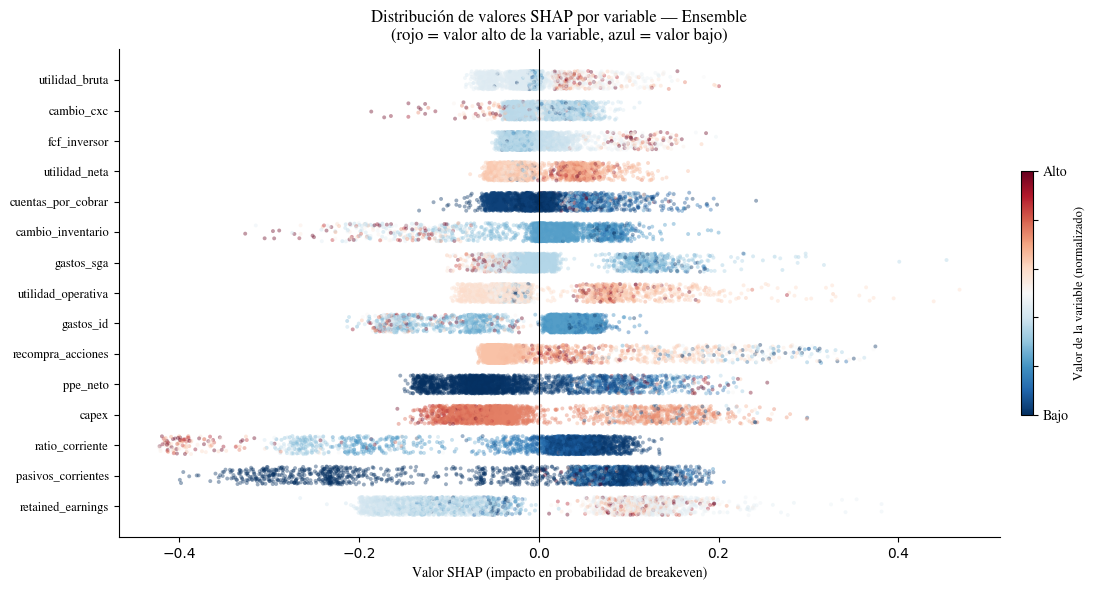

In [4]:
top15_vars = importancia_global.head(15).index.tolist()
cmap_bee   = plt.cm.RdBu_r

fig, ax = plt.subplots(figsize=(12, 6))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, var in enumerate(top15_vars):
    idx_var   = features_con_momentum.index(var)
    shap_var  = sv[:, idx_var]
    feat_var  = X_rf[:, idx_var]  # usar X_rf como referencia

    p1, p99   = np.nanpercentile(feat_var, [1, 99])
    feat_norm = np.clip((feat_var - p1) / (p99 - p1 + 1e-10), 0, 1)
    colores_pts = cmap_bee(feat_norm)

    y_pos = np.random.uniform(i - 0.3, i + 0.3, size=len(shap_var))
    ax.scatter(shap_var, y_pos, c=colores_pts, alpha=0.4, s=8, linewidths=0)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(range(len(top15_vars)))
ax.set_yticklabels(top15_vars, fontfamily=FUENTE, fontsize=9)
ax.set_xlabel("Valor SHAP (impacto en probabilidad de breakeven)", fontfamily=FUENTE)
ax.set_title("Distribución de valores SHAP por variable — Ensemble\n"
             "(rojo = valor alto de la variable, azul = valor bajo)",
             fontfamily=FUENTE, fontsize=12)

sm = ScalarMappable(cmap=cmap_bee, norm=Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label("Valor de la variable (normalizado)", fontfamily=FUENTE, fontsize=9)
cbar.ax.set_yticklabels(["Bajo", "", "", "", "", "Alto"], fontfamily=FUENTE)

plt.tight_layout()
plt.show()

## 4. Explicaciones individuales — Waterfall plots

El waterfall muestra cómo cada variable empuja la predicción para una empresa específica. Las barras a la derecha favorecen el breakeven; las barras a la izquierda lo desfavorecen.

Se analizan tres empresas contrastantes del año 2024:

| Empresa | Sector | Prob. predicha | Y real | Perfil |
|---|---|---|---|---|
| **FCFS** | Retail-Miscellaneous | 0.918 | Y=1 ✓ | Alta probabilidad — modelo acertó |
| **LRMR** | Pharmaceutical | 0.024 | Y=0 ✓ | Baja probabilidad — modelo acertó |
| **CRI** | Apparel & Fabrics | 0.458 | Y=0 | Zona de incertidumbre — modelo dudó |

### Glosario de variables clave

- **`retained_earnings`**: ganancias acumuladas históricamente desde la fundación. Positivo = empresa ha sido rentable en el agregado; negativo = pérdidas acumuladas
- **`capex`**: inversión en activos físicos de largo plazo (maquinaria, edificios, equipos). Aparece negativo porque es una salida de caja. Una empresa que invierte en CAPEX apuesta por su crecimiento futuro
- **`pasivos_corrientes`**: obligaciones de corto plazo — deudas que vencen en menos de un año
- **`ratio_corriente`**: activos corrientes dividido pasivos corrientes — mide la liquidez de corto plazo

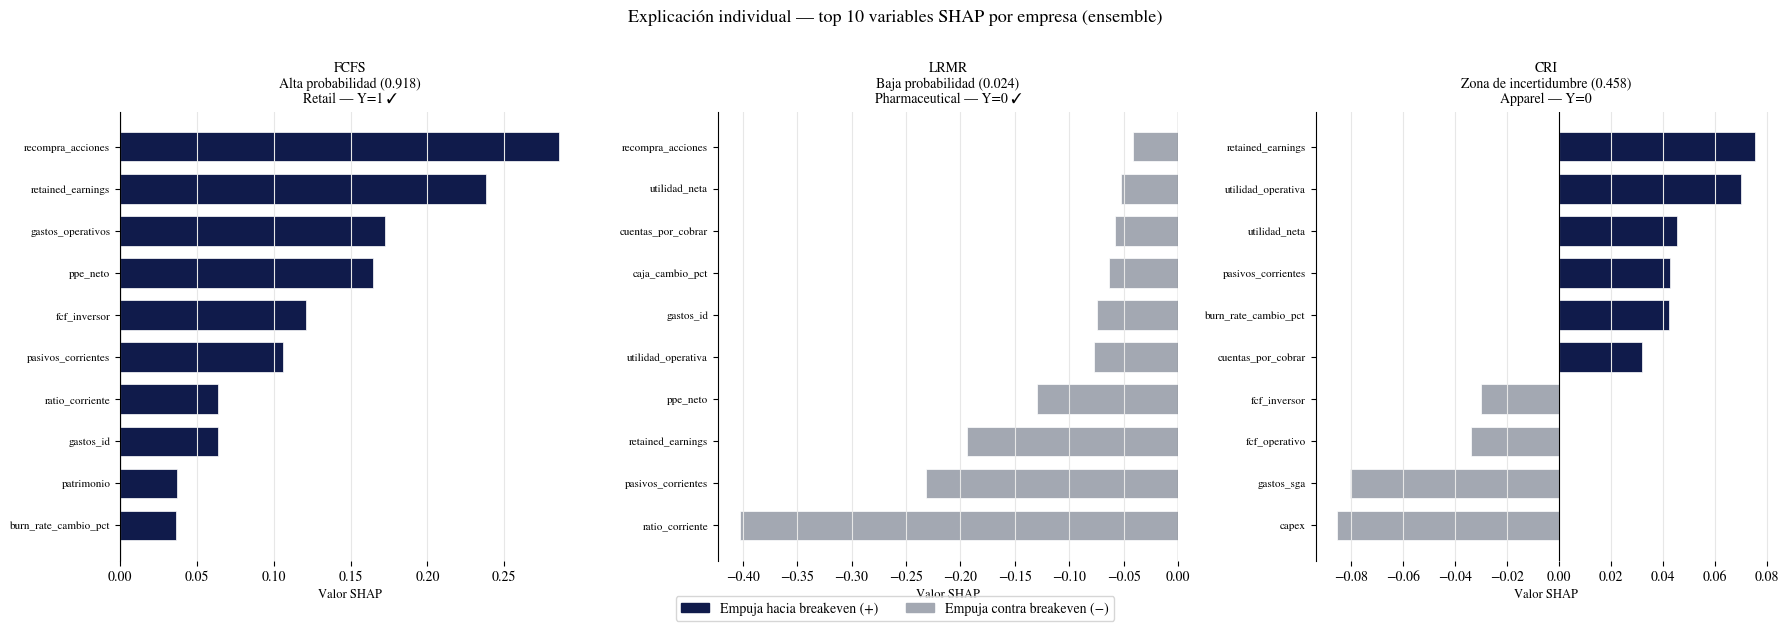

In [5]:
idx_alta  = df_2024[df_2024["prob_breakeven"] > 0.85].nlargest(1, "prob_breakeven").index[0]
idx_baja  = df_2024[df_2024["prob_breakeven"] < 0.10].nsmallest(1, "prob_breakeven").index[0]
idx_media = df_2024[(df_2024["prob_breakeven"] > 0.45) &
                    (df_2024["prob_breakeven"] < 0.55)].sample(1, random_state=42).index[0]

empresas = [
    (idx_alta,  "FCFS", "Alta probabilidad (0.918)\nRetail — Y=1 ✓"),
    (idx_baja,  "LRMR", "Baja probabilidad (0.024)\nPharmaceutical — Y=0 ✓"),
    (idx_media, "CRI",  "Zona de incertidumbre (0.458)\nApparel — Y=0"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (idx, ticker, titulo) in zip(axes, empresas):
    shap_emp = pd.Series(sv[idx], index=features_con_momentum)
    top10    = shap_emp.abs().nlargest(10).index
    shap_top = shap_emp[top10].sort_values()

    colores_wf = [juan_colors[0] if v > 0 else juan_colors[2]
                  for v in shap_top.values]
    ax.barh(range(len(shap_top)), shap_top.values,
            color=colores_wf, edgecolor="white", linewidth=0.5, height=0.7)
    ax.set_yticks(range(len(shap_top)))
    ax.set_yticklabels(shap_top.index, fontfamily=FUENTE, fontsize=8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{ticker}\n{titulo}", fontfamily=FUENTE, fontsize=10)
    ax.set_xlabel("Valor SHAP", fontfamily=FUENTE, fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.xaxis.grid(True, linestyle="-", color=juan_colors[3], linewidth=0.8)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)

patch_pos = mpatches.Patch(color=juan_colors[0], label="Empuja hacia breakeven (+)")
patch_neg = mpatches.Patch(color=juan_colors[2], label="Empuja contra breakeven (−)")
fig.legend(handles=[patch_pos, patch_neg], prop={"family": FUENTE},
           loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Explicación individual — top 10 variables SHAP por empresa (ensemble)",
             fontfamily=FUENTE, fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Dependence plots

Los dependence plots muestran cómo cambia el impacto de una variable según su valor. Revelan si la relación es lineal, si existe un umbral crítico, o si es no lineal — algo que los modelos de árboles capturan pero los modelos lineales no.

El color de cada punto indica la probabilidad predicha de breakeven: rojo = alta probabilidad, azul = baja probabilidad.

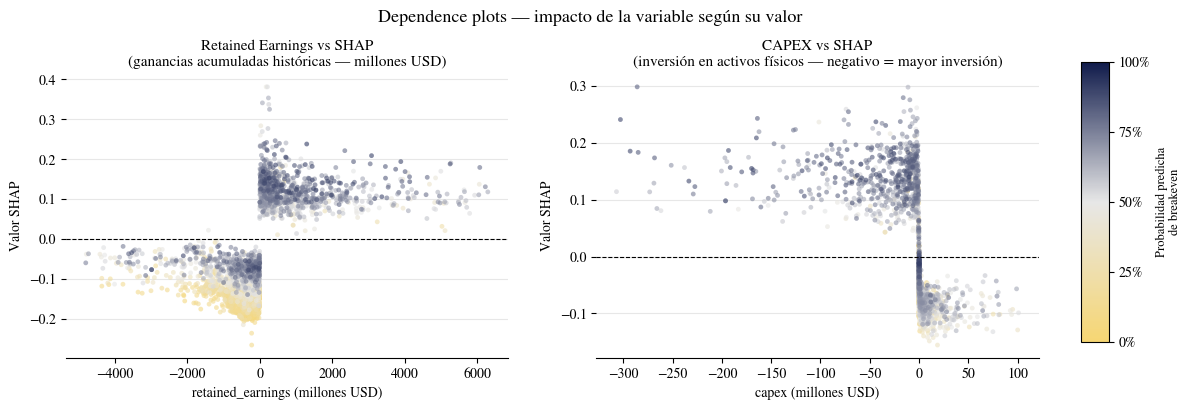

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vars_dep = ["retained_earnings", "capex"]
titulos  = [
    "Retained Earnings vs SHAP\n(ganancias acumuladas históricas — millones USD)",
    "CAPEX vs SHAP\n(inversión en activos físicos — negativo = mayor inversión)"
]

cmap_dep = LinearSegmentedColormap.from_list(
    "juan_dep", [juan_colors[5], juan_colors[3], juan_colors[0]], N=256
)
norm_dep = Normalize(vmin=0, vmax=1)

for ax, var, titulo in zip(axes, vars_dep, titulos):
    estilo_ax(ax)
    idx_var   = features_con_momentum.index(var)
    x_vals    = X_rf[:, idx_var]
    shap_vals = sv[:, idx_var]

    colores_dep = cmap_dep(norm_dep(df_2024["prob_breakeven"].values))
    p1, p99 = np.nanpercentile(x_vals, [1, 99])
    mask = (x_vals >= p1) & (x_vals <= p99)

    orden  = np.argsort(df_2024["prob_breakeven"].values[mask])
    x_plot = x_vals[mask][orden] / 1e6
    y_plot = shap_vals[mask][orden]
    c_plot = colores_dep[mask][orden]

    ax.scatter(x_plot, y_plot, c=c_plot, alpha=0.6, s=12, linewidths=0)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(titulo, fontfamily=FUENTE, fontsize=11)
    ax.set_xlabel(f"{var} (millones USD)", fontfamily=FUENTE)
    ax.set_ylabel("Valor SHAP", fontfamily=FUENTE)

fig.subplots_adjust(right=0.82, top=0.82)
cax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
sm  = ScalarMappable(cmap=cmap_dep, norm=norm_dep)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Probabilidad predicha\nde breakeven", fontfamily=FUENTE, fontsize=9)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"], fontfamily=FUENTE)

fig.suptitle("Dependence plots — impacto de la variable según su valor",
             fontfamily=FUENTE, fontsize=13, y=0.98)
plt.show()

## 6. Análisis por sector

Los cinco sectores con más observaciones en 2024 tienen dinámicas financieras muy diferentes. El análisis SHAP por sector revela qué variables son más discriminantes en cada industria.

**Hallazgos clave:**
- **Pharma y Biotech**: `ratio_corriente` y `retained_earnings` lideran — la liquidez y el historial de pérdidas en I+D son las señales más importantes para empresas que queman caja en investigación
- **Software**: `pasivos_corrientes` lidera sobre `capex` — al tener pocos activos físicos, las obligaciones de corto plazo son la señal más discriminante
- **Semiconductores**: `retained_earnings` y `capex` compiten — industria intensiva en capital con ciclos de inversión muy largos

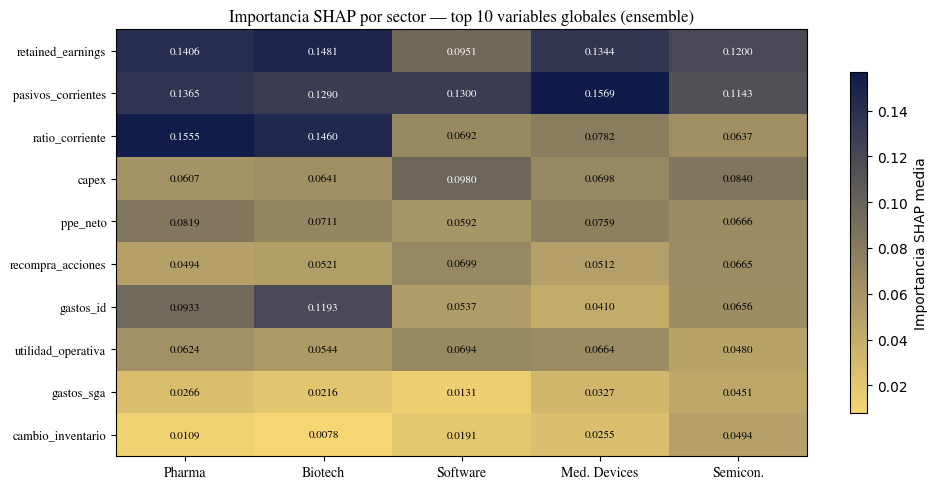

In [13]:
top5_sectores = df_2024["sector"].value_counts().head(5).index.tolist()
nombres_cortos = {
    "Pharmaceutical Preparations": "Pharma",
    "Biological Products, (No Diagnostic Substances)": "Biotech",
    "Services-Prepackaged Software": "Software",
    "Surgical & Medical Instruments & Apparatus": "Med. Devices",
    "Semiconductors & Related Devices": "Semicon.",
}

top10_vars = importancia_global.head(10).index.tolist()

shap_por_sector = {}
for sector in top5_sectores:
    mask = df_2024["sector"].values == sector
    shap_por_sector[sector] = pd.Series(
        np.abs(sv[mask]).mean(axis=0),
        index=features_con_momentum
    )

matriz_sector = pd.DataFrame(
    {nombres_cortos[s]: shap_por_sector[s][top10_vars] for s in top5_sectores}
)

cmap_heat = LinearSegmentedColormap.from_list(
    "juan", [juan_colors[5], juan_colors[0]], N=256
)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(matriz_sector.values, cmap=cmap_heat, aspect="auto")
plt.colorbar(im, ax=ax, shrink=0.8, label="Importancia SHAP media")

ax.set_xticks(range(len(matriz_sector.columns)))
ax.set_yticks(range(len(top10_vars)))
ax.set_xticklabels(matriz_sector.columns, fontfamily=FUENTE, fontsize=10)
ax.set_yticklabels(top10_vars, fontfamily=FUENTE, fontsize=9)

umbral = matriz_sector.values.max() * 0.6
for i in range(len(top10_vars)):
    for j in range(len(matriz_sector.columns)):
        val   = matriz_sector.values[i, j]
        color = "white" if val > umbral else "black"
        ax.text(j, i, f"{val:.4f}", ha="center", va="center",
                fontsize=8, color=color, fontfamily=FUENTE)

ax.set_title("Importancia SHAP por sector — top 10 variables globales (ensemble)",
             fontfamily=FUENTE, fontsize=12)
plt.tight_layout()
plt.show()

## 7. Separación del modelo

Un buen modelo asigna probabilidades altas a las empresas que realmente alcanzan el breakeven (Y=1) y bajas a las que no (Y=0). Esta sección cuantifica qué tan bien logra el ensemble separar ambas clases.

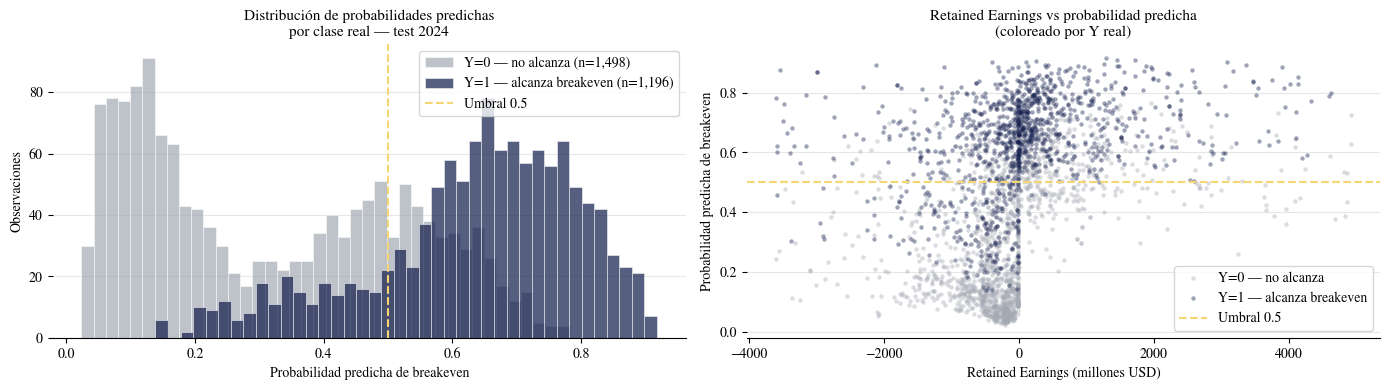

Probabilidad media predicha para empresas que NO alcanzaron breakeven (Y=0): 0.318
Probabilidad media predicha para empresas que SÍ alcanzaron breakeven (Y=1): 0.634
Diferencia: 0.316
→ El ensemble asigna en promedio 31.6 puntos porcentuales más de probabilidad
  a las empresas que realmente alcanzaron el breakeven — confirma que el modelo separa bien ambas clases


In [8]:
prob_y0 = df_2024[df_2024["Y"] == 0]["prob_breakeven"]
prob_y1 = df_2024[df_2024["Y"] == 1]["prob_breakeven"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel izquierdo — histograma de probabilidades por Y real
estilo_ax(axes[0])
axes[0].hist(prob_y0, bins=40, alpha=0.7, color=juan_colors[2],
             label=f"Y=0 — no alcanza (n={len(prob_y0):,})",
             edgecolor="white", linewidth=0.5)
axes[0].hist(prob_y1, bins=40, alpha=0.7, color=juan_colors[0],
             label=f"Y=1 — alcanza breakeven (n={len(prob_y1):,})",
             edgecolor="white", linewidth=0.5)
axes[0].axvline(0.5, color=juan_colors[5], linewidth=1.5,
                linestyle="--", label="Umbral 0.5")
axes[0].set_title("Distribución de probabilidades predichas\npor clase real — test 2024",
                  fontfamily=FUENTE, fontsize=11)
axes[0].set_xlabel("Probabilidad predicha de breakeven", fontfamily=FUENTE)
axes[0].set_ylabel("Observaciones", fontfamily=FUENTE)
axes[0].legend(prop={"family": FUENTE}, fontsize=9)

# Panel derecho — retained_earnings vs probabilidad
estilo_ax(axes[1])
idx_re = features_con_momentum.index("retained_earnings")
re_vals = X_rf[:, idx_re] / 1e6
p1, p99 = np.nanpercentile(re_vals, [2, 98])
mask = (re_vals >= p1) & (re_vals <= p99)

y0_mask = mask & (df_2024["Y"].values == 0)
y1_mask = mask & (df_2024["Y"].values == 1)

axes[1].scatter(re_vals[y0_mask], df_2024["prob_breakeven"].values[y0_mask],
                color=juan_colors[2], alpha=0.4, s=10, linewidths=0,
                label="Y=0 — no alcanza")
axes[1].scatter(re_vals[y1_mask], df_2024["prob_breakeven"].values[y1_mask],
                color=juan_colors[0], alpha=0.4, s=10, linewidths=0,
                label="Y=1 — alcanza breakeven")
axes[1].axhline(0.5, color=juan_colors[5], linewidth=1.5,
                linestyle="--", label="Umbral 0.5")
axes[1].set_title("Retained Earnings vs probabilidad predicha\n(coloreado por Y real)",
                  fontfamily=FUENTE, fontsize=11)
axes[1].set_xlabel("Retained Earnings (millones USD)", fontfamily=FUENTE)
axes[1].set_ylabel("Probabilidad predicha de breakeven", fontfamily=FUENTE)
axes[1].legend(prop={"family": FUENTE}, fontsize=9)

plt.tight_layout()
plt.show()

diferencia = prob_y1.mean() - prob_y0.mean()
print(f"Probabilidad media predicha para empresas que NO alcanzaron breakeven (Y=0): {prob_y0.mean():.3f}")
print(f"Probabilidad media predicha para empresas que SÍ alcanzaron breakeven (Y=1): {prob_y1.mean():.3f}")
print(f"Diferencia: {diferencia:.3f}")
print(f"→ El ensemble asigna en promedio {diferencia*100:.1f} puntos porcentuales más de probabilidad")
print(f"  a las empresas que realmente alcanzaron el breakeven — confirma que el modelo separa bien ambas clases")

## 8. Conclusiones

### Variables más importantes del ensemble

La siguiente tabla muestra las 5 variables con mayor importancia SHAP global — es decir, las que en promedio tienen mayor impacto en las predicciones del ensemble sobre las 2.694 observaciones de 2024. Los valores indican el impacto absoluto promedio en puntos de probabilidad.

| Variable | SHAP global | Interpretación |
|---|---|---|
| `retained_earnings` | 0.1192 | El historial acumulado de rentabilidad desde la fundación es la señal más fuerte — empresas con ganancias acumuladas positivas tienen ventaja estructural |
| `pasivos_corrientes` | 0.1094 | Las obligaciones de corto plazo determinan la presión sobre la caja — a mayor deuda de corto plazo, menor probabilidad de breakeven |
| `ratio_corriente` | 0.0826 | Alta liquidez paradójicamente desfavorece el breakeven — empresas que acumulan caja lo hacen precisamente porque queman efectivo y necesitan reservas |
| `capex` | 0.0813 | La inversión en activos físicos señala confianza en el crecimiento futuro, aunque consume caja en el corto plazo |
| `ppe_neto` | 0.0744 | Los activos físicos netos reflejan la capacidad instalada del negocio — empresas con mayor infraestructura tienen más base para generar FCF positivo |

### Diferencias por sector

- **Pharma y Biotech**: `ratio_corriente` y `retained_earnings` dominan — la liquidez y el historial de pérdidas acumuladas en I+D son las señales más importantes para empresas que queman caja en investigación de largo plazo
- **Software**: `pasivos_corrientes` lidera — al tener pocos activos físicos, las obligaciones de corto plazo son la señal más discriminante
- **Semiconductores**: `retained_earnings` y `capex` compiten en importancia — industria intensiva en capital con ciclos de inversión muy largos

### Valor para el inversionista

La explicabilidad SHAP transforma el modelo de una caja negra en una herramienta de análisis accionable. Un inversionista puede no solo saber que el modelo predice un 92% de probabilidad de breakeven para FCFS, sino **por qué**: qué variables específicas impulsan esa predicción y cuáles la frenan. Para LRMR, con solo 2.4% de probabilidad, el análisis muestra que `ratio_corriente` y `retained_earnings` negativos son las señales de alarma más fuertes. Esto facilita la validación humana de la predicción y aumenta la confianza en la decisión de inversión.